In [1]:
import ecanalytics as ecx
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

ecx.reset(ecx.Experiment)
palmsens_swollen = ecx.Experiment("PalmSens - DPBS Swelling").load(
    "/Users/nathan/Documents/Jülich/Messungen/2026-01-28/eis-data/PalmSens"
)
palmsens_non_swollen = ecx.Experiment("PalmSens - Just DI Water Swelling").load(
    "/Users/nathan/Documents/Jülich/Messungen/2025-12-17/eis-data/NoMG"
)

biologic_swollen = ecx.Experiment("BioLogic Swollen").load(
    "/Users/nathan/Documents/Jülich/Messungen/2026-01-23/eis-data/MG"
)
# ds = ecx.Experiment("BioLogic NotSwollen").load("/Users/nathan/Documents/Jülich/Messungen/2025-11-27/EIS/BioLogic")

In [2]:
from tabulate import tabulate, SEPARATING_LINE

quality = palmsens_swollen.quality

Calculating Kramers-Kronig Tests for EIS Experiment 'PalmSens - DPBS Swelling': 100%|██████████| 4/4 [00:36<00:00,  9.20s/it]


/Users/nathan/Documents/Jülich/lab-analytics/ecanalytics/src/plot/plot.py:108: UserWarning: 
The palette list has fewer values (0) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(**sns_args, sort=False)


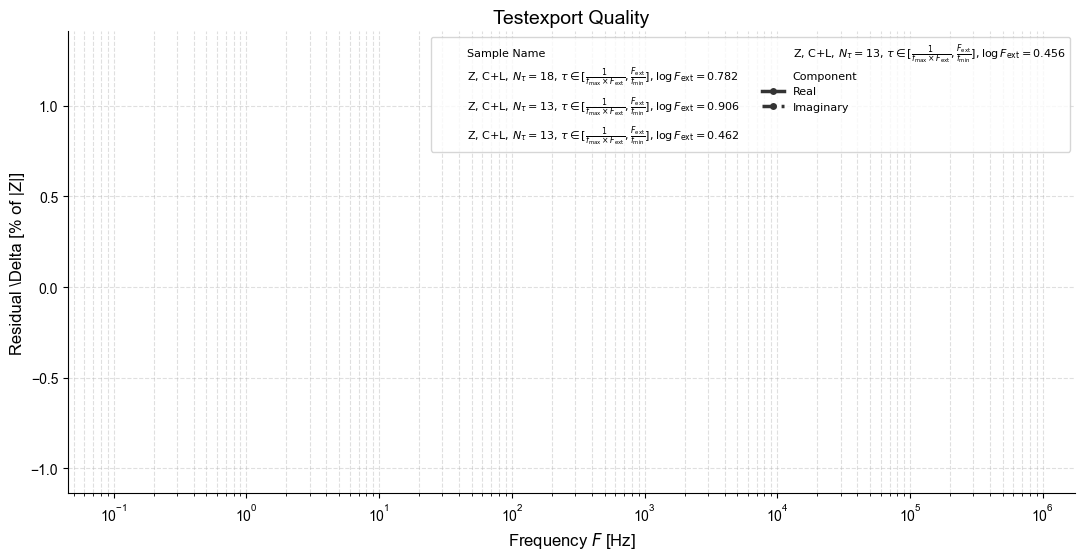

In [3]:
ecx.residuals(quality, "Testexport Quality").save()

# Stat_Labels = ["Log pseudo chi-squared",
#                      "Estimated SD of Gaussian noise (% of |Z|)",
#                      "Mean of residuals, real (% of |Z|)",
#                      "Mean of residuals, imag. (% of |Z|)",
#                      "SD of residuals, real (% of |Z|)",
#                      "SD of residuals, imag. (% of |Z|)"]

# results = quality._results


# residuals = list()

# for kk_result in


# residuals = [ (pd.DataFrame(r.get_residuals_data()), r.get_label()) for r in results ]

# stats = pd.concat([
#             r.to_statistics_dataframe().set_index("Label")["Value"].reindex(Stat_Labels)
#             for r in results
#         ],
#         ignore_index=True, axis=1)

# print([r.to_statistics_dataframe() for r in results])

# print(pd.DataFrame(np.array(residuals)).to_string())

In [ ]:
peaks = pd.DataFrame(
    {
        "Max. Real Residual [%]": [max(residual[1], key=abs) for residual in residuals],
        "Max. Imag. Residual [%]": [
            max(residual[2], key=abs) for residual in residuals
        ],
    }
).transpose()

stats = pd.concat([stats, peaks], axis=0).transpose()
stats.columns = [
    "Decadic Logarithm of\nPseudo Chi-Squared",
    "Estimated SD of\n Gaussian Noise [%]",
    "Real Residual Mean [%]",
    "Imag. Residual Mean [%]",
    "Real Residual SD [%]",
    "Imag. Residual SD [%]",
    "Max. Real Residual [%]",
    "Max. Imag. Residual [%]",
]

stats = pd.concat(
    [pd.DataFrame({"Sample": [f"Experiment_{i}" for i in range(len(stats))]}), stats],
    axis=1,
)

mean_stats = stats.mean(numeric_only=True)
mean_stats["Decadic Logarithm of\nPseudo Chi-Squared"] = np.log10(
    np.mean(10 ** stats["Decadic Logarithm of\nPseudo Chi-Squared"])
)
mean_stats["Max. Real Residual [%]"] = np.mean(np.abs(stats["Max. Real Residual [%]"]))
mean_stats["Max. Imag. Residual [%]"] = np.mean(
    np.abs(stats["Max. Imag. Residual [%]"])
)
mean_stats = pd.concat(
    [pd.DataFrame({"Sample": ["Mean"]}), mean_stats.to_frame().transpose()], axis=1
)

stats = pd.concat([stats, mean_stats], ignore_index=True)

printable_stats = stats.copy()


def bigred(x: str) -> str:
    return f"\033[1m\033[31m{x}\033[0m"


def big(x: str) -> str:
    return f"\033[1m{x}\033[0m"


def check_threshold(v: float, thr: float, abs: bool = True) -> str:
    x = f"{v:.3f}"
    if abs:
        return bigred(x) if np.abs(v) > thr else x
    else:
        return bigred(x) if v > thr else x


chi_squared_threshold = np.log10(
    0.01**2 * len(residuals[0][0])
)  # Example threshold for chi-squared, adjust as needed
print(f"Chi Squared Threshold: {chi_squared_threshold:.3f}")

fmts = [
    lambda x: check_threshold(x, chi_squared_threshold, False),  # Chi Squared
    lambda x: check_threshold(x, 1),  # Gaussian Noise SD
    lambda x: check_threshold(x, 1),  # Real Residual Mean
    lambda x: check_threshold(x, 1),  # Imag Residual Mean
    lambda x: check_threshold(x, 1),  # Real Residual SD
    lambda x: check_threshold(x, 1),  # Imag Residual SD
    lambda x: check_threshold(x, 1),  # Max Real Residual
    lambda x: check_threshold(x, 1),  # Max Imag Residual
]

for col, fmt in zip(printable_stats.columns[1:], fmts):
    printable_stats[col] = printable_stats[col].apply(fmt)

printable_stats["Real Residual Stats [%]\nMean  ±   SD  : Peak"] = (
    printable_stats["Real Residual Mean [%]"]
    + " ± "
    + printable_stats["Real Residual SD [%]"]
    + " : "
    + printable_stats["Max. Real Residual [%]"]
)
printable_stats["Imag. Residual Stats [%]\nMean  ±   SD  : Peak"] = (
    printable_stats["Imag. Residual Mean [%]"]
    + " ± "
    + printable_stats["Imag. Residual SD [%]"]
    + " : "
    + printable_stats["Max. Imag. Residual [%]"]
)

printable_stats = printable_stats.drop(
    columns=[
        "Real Residual Mean [%]",
        "Real Residual SD [%]",
        "Max. Real Residual [%]",
        "Imag. Residual Mean [%]",
        "Imag. Residual SD [%]",
        "Max. Imag. Residual [%]",
    ]
)

printable_stats.iloc[-1] = printable_stats.iloc[-1].map(lambda x: big(x))

table_data = printable_stats.values.tolist()
table_data.insert(-1, SEPARATING_LINE)

print(
    tabulate(
        table_data, headers=printable_stats.columns, tablefmt="psql", showindex=False
    )
)

In [ ]:
from ecanalytics.src.palette import NEIColorPalette

gdf = pd.DataFrame()

names = [sample._name[9:] for sample in ds._Experiment__samples]

for r, name in zip(residuals, names):
    df = pd.DataFrame(r).transpose()

    dfr = df.iloc[:, [0, 1]]
    dfr["Component"] = "Real"

    dfi = df.iloc[:, [0, 2]]
    dfi["Component"] = "Imaginary"

    dfi.columns = dfr.columns

    df = pd.concat([dfr, dfi], axis=0, ignore_index=True)
    df["Sample"] = name

    df.columns = ["Frequency", "Phase", "Component", "Sample"]

    gdf = pd.concat([gdf, df], axis=0, ignore_index=True)


# print(gdf.to_string())

gdf["Palette"] = NEIColorPalette(
    "green"
)  # Assuming all samples have the same palette, otherwise this needs to be adjusted

pres = ecx.plot(
    gdf,
    x="Frequency",
    y="Phase",
    hue="Sample",
    style="Component",
    title="Residuals of Kramers-Kronig Test for PalmSens Data in Faraday Cage",
)

with pres as (fig, ax):
    fig.set_size_inches(13, 6)
    sns.move_legend(ax, "upper right", ncol=2, fontsize="small")
    ax.set_ylabel("Residual [% of |Z|]")

plt.show()

In [ ]:
only_res = [(r[1], r[2]) for r in residuals]

only_res = np.concatenate([(r[1], r[2]) for r in residuals], axis=1)

print(only_res.shape)

In [ ]:
from ecanalytics.src.config import FIGURE_SETTINGS
from matplotlib.colors import to_rgba
from scipy.stats import norm

with plt.rc_context(FIGURE_SETTINGS):
    c = NEIColorPalette("green").shade(1)[0]
    fig = plt.figure()
    joint = sns.jointplot(
        x=only_res[0],
        y=only_res[1],
        joint_kws={"color": c},
        marginal_kws={"facecolor": to_rgba(c, 0.5), "edgecolor": c, "stat": "density"},
    )

    fig = joint.figure

    fig.suptitle(f"Joint Distribution of the Residuals of {ds.name}")
    fig.subplots_adjust(top=0.94)

    axes = fig.axes

    max = np.max((np.max(np.abs(only_res)), 1))
    print(max)
    lims = (-1.05 * max, 1.05 * max)

    scatter_ax = axes[0]
    scatter_ax.set(
        xlabel="Real Residual [% of |Z|]",
        ylabel="Imaginary Residual [% of |Z|]",
        xlim=lims,
        ylim=lims,
    )
    scatter_ax.grid(True, which="both", linestyle="--", alpha=0.4)

    for i, (ax, data) in enumerate(zip(axes[1:], only_res)):
        zero_centered_std = np.sqrt(np.mean(data**2))

        # X-Werte für die perfekte Kurve generieren (von -3*std bis +3*std)
        x_werte = np.linspace(-3 * zero_centered_std, 3 * zero_centered_std, 100)
        # Y-Werte (Wahrscheinlichkeitsdichte) der perfekten Gaußglocke berechnen (loc=0 zentriert sie auf die Null)
        y_werte = norm.pdf(x_werte, loc=0, scale=zero_centered_std)

        if i == 0:
            ax.plot(x_werte, y_werte, color=c, linestyle="--")
        else:
            ax.plot(y_werte, x_werte, color=c, linestyle="--")

    joint.refline(x=0, y=0, linewidth=0.75, marginal=True, zorder=0, linestyle="-.")


plt.show()

In [ ]:
from scipy.stats import norm, skew

plt.figure()
sns.histplot(
    only_res,
    bins=75,
    binrange=(-2, 2),
    stat="density",
    color=NEIColorPalette("orange").shade(1)[0],
)
std_dev = np.std(only_res)

# X-Werte für die perfekte Kurve generieren (von -3*std bis +3*std)
x_werte = np.linspace(-3 * std_dev, 3 * std_dev, 100)
# Y-Werte (Wahrscheinlichkeitsdichte) der perfekten Gaußglocke berechnen (loc=0 zentriert sie auf die Null)
y_werte = norm.pdf(x_werte, loc=0, scale=np.sqrt(np.mean(only_res**2)))

# 4. Die perfekte Gaußglocke plotten
plt.gca().plot(
    x_werte,
    y_werte,
    color="red",
    linestyle="--",
    label="Perfekte Gaußglocke (Mittelwert=0)",
)


from scipy.optimize import curve_fit


# 1. Wir definieren eine strikt null-zentrierte Gauß-Funktion
def zero_centered_gaussian(x, amplitude, sigma):
    return amplitude * np.exp(-0.5 * (x / sigma) ** 2)


# 2. Wir erzeugen ein Histogramm unserer Daten (als Basis für den Fit)
counts, bin_edges = np.histogram(only_res, bins=50, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Die Mitte jedes Balkens

# 3. Den Algorithmus die beste Amplitude und das beste Sigma finden lassen
# p0 sind Startschätzungen (Amplitude=1, Sigma=1)
popt, pcov = curve_fit(zero_centered_gaussian, bin_centers, counts, p0=[1.0, 1.0])

best_amplitude, best_sigma_visual = popt

# 4. Plotten
y_fit = zero_centered_gaussian(x_werte, best_amplitude, best_sigma_visual)
plt.gca().plot(
    x_werte, y_fit, color="green", linestyle=":", label="Visueller Fit (curve_fit)"
)


plt.show()


print(skew(only_res))

## Skew
- Biologic, Swollen: 0.83313
- PalmSens, NonSwollen: 0.368879